In [1]:
# --- IMPORTS ---
import os
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

print("[INFO] Libraries loaded successfully")

[INFO] Libraries loaded successfully


In [2]:
# --- CONFIGURATION ---
base_dir = r""

files_vars = {
    "Dominant_Drought_Type_AllPeriod.nc": "dominant_drought_type_allperiod",
    "Dominant_Drought_Type_February.nc":  "dominant_drought_type_february",
    "Dominant_Drought_Type_May.nc":       "dominant_drought_type_may",
    "Dominant_Drought_Type_August.nc":    "dominant_drought_type_august",
    "Dominant_Drought_Type_November.nc":  "dominant_drought_type_november",
}

# Category labels
labels = {
    1: "Compound",
    2: "Hydrological",
    3: "ET-driven",
    4: "Soil-anomaly"
}

# Fixed colors for categories
colors = ['#2166ac', '#1a9850', '#fdae61', '#b2182b']

cmap = ListedColormap(colors)
norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

# Northern Africa extent
extent = [-20, 40, 15, 40]

print("[INFO] Configuration loaded")

[INFO] Configuration loaded


In [5]:
# --- HELPER FUNCTIONS ---

def find_coords(da):
    """Return lon and lat coordinates dynamically"""
    lon_name = next(n for n in da.coords if n.lower() in ("lon","longitude","x"))
    lat_name = next(n for n in da.coords if n.lower() in ("lat","latitude","y"))
    return da[lon_name], da[lat_name]


def plot_one(path, varname, title_suffix):
    
    print(f"[INFO] Processing: {os.path.basename(path)}")
    
    if not os.path.exists(path):
        print(f"[WARNING] File not found: {path}")
        return
    
    ds = xr.open_dataset(path)
    
    print("[DEBUG] Available variables:", list(ds.data_vars))
    
    if varname not in ds.data_vars:
        varname = list(ds.data_vars)[0]
        print(f"[WARNING] Using variable: {varname}")
    
    da = ds[varname].squeeze()
    
    lon, lat = find_coords(da)

    proj = ccrs.PlateCarree()
    
    fig = plt.figure(figsize=(10, 5), dpi=300)
    ax = plt.axes(projection=proj)
    
    ax.set_extent(extent, crs=proj)

    # --- BASE MAP ---
    ax.add_feature(cfeature.LAND, facecolor='0.92', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    # --- GRIDLINES ---
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='0.5',
                      alpha=0.6, linestyle='--')
    gl.right_labels = False
    gl.top_labels = False

    # --- CATEGORICAL MAP ---
    ax.pcolormesh(
        lon, lat, da.values,
        cmap=cmap, norm=norm,
        transform=proj,
        shading='nearest'
    )

    # --- LEGEND ---
    handles = [
        Patch(facecolor=colors[i-1], label=f"{i} — {labels[i]}")
        for i in (1, 2, 3, 4)
    ]
    
    leg = ax.legend(
        handles=handles,
        loc='lower left',
        frameon=True,
        title="Dominant type"
    )
    leg.get_frame().set_alpha(0.9)

    # --- TITLE ---
    ax.set_title(
        f"Dominant Drought Type — {title_suffix} (categories 1–4)",
        fontsize=12,
        fontweight="bold"
    )

    plt.tight_layout()

    # --- SAVE ---
    out_png = os.path.join(
        os.path.dirname(path),
        f"{os.path.splitext(os.path.basename(path))[0]}.png"
    )

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

  #  print(f"[SAVED] {out_png}")



[INFO] Starting plotting...
[INFO] Processing: Dominant_Drought_Type_AllPeriod.nc
[DEBUG] Available variables: ['dominant_drought_type_allperiod']


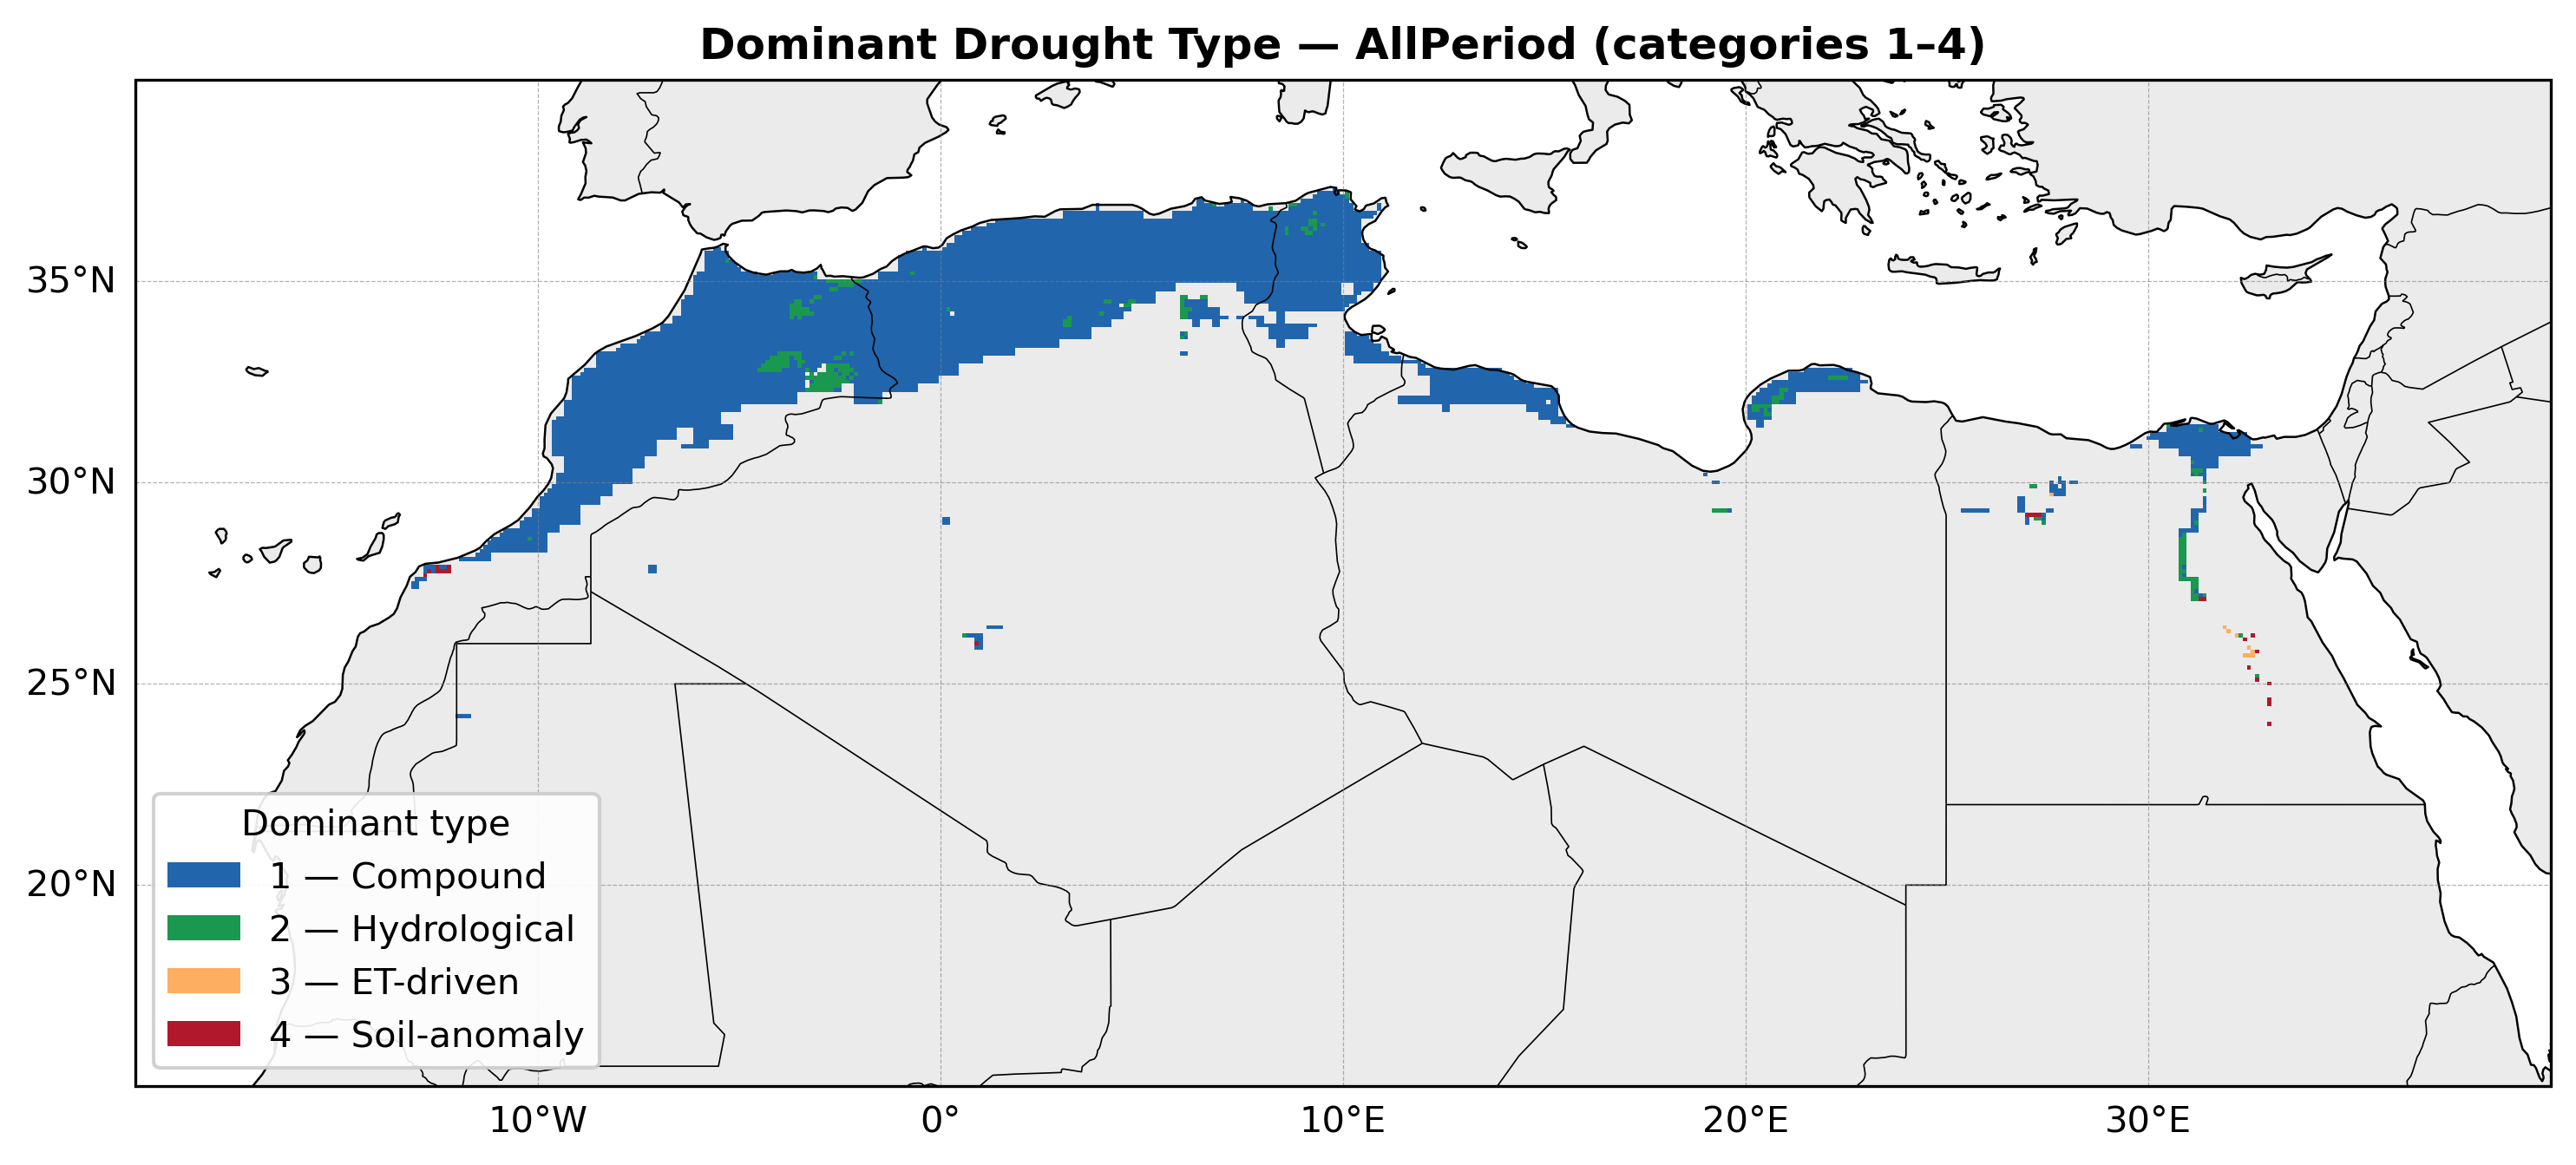

[INFO] Processing: Dominant_Drought_Type_February.nc
[DEBUG] Available variables: ['dominant_drought_type_february']


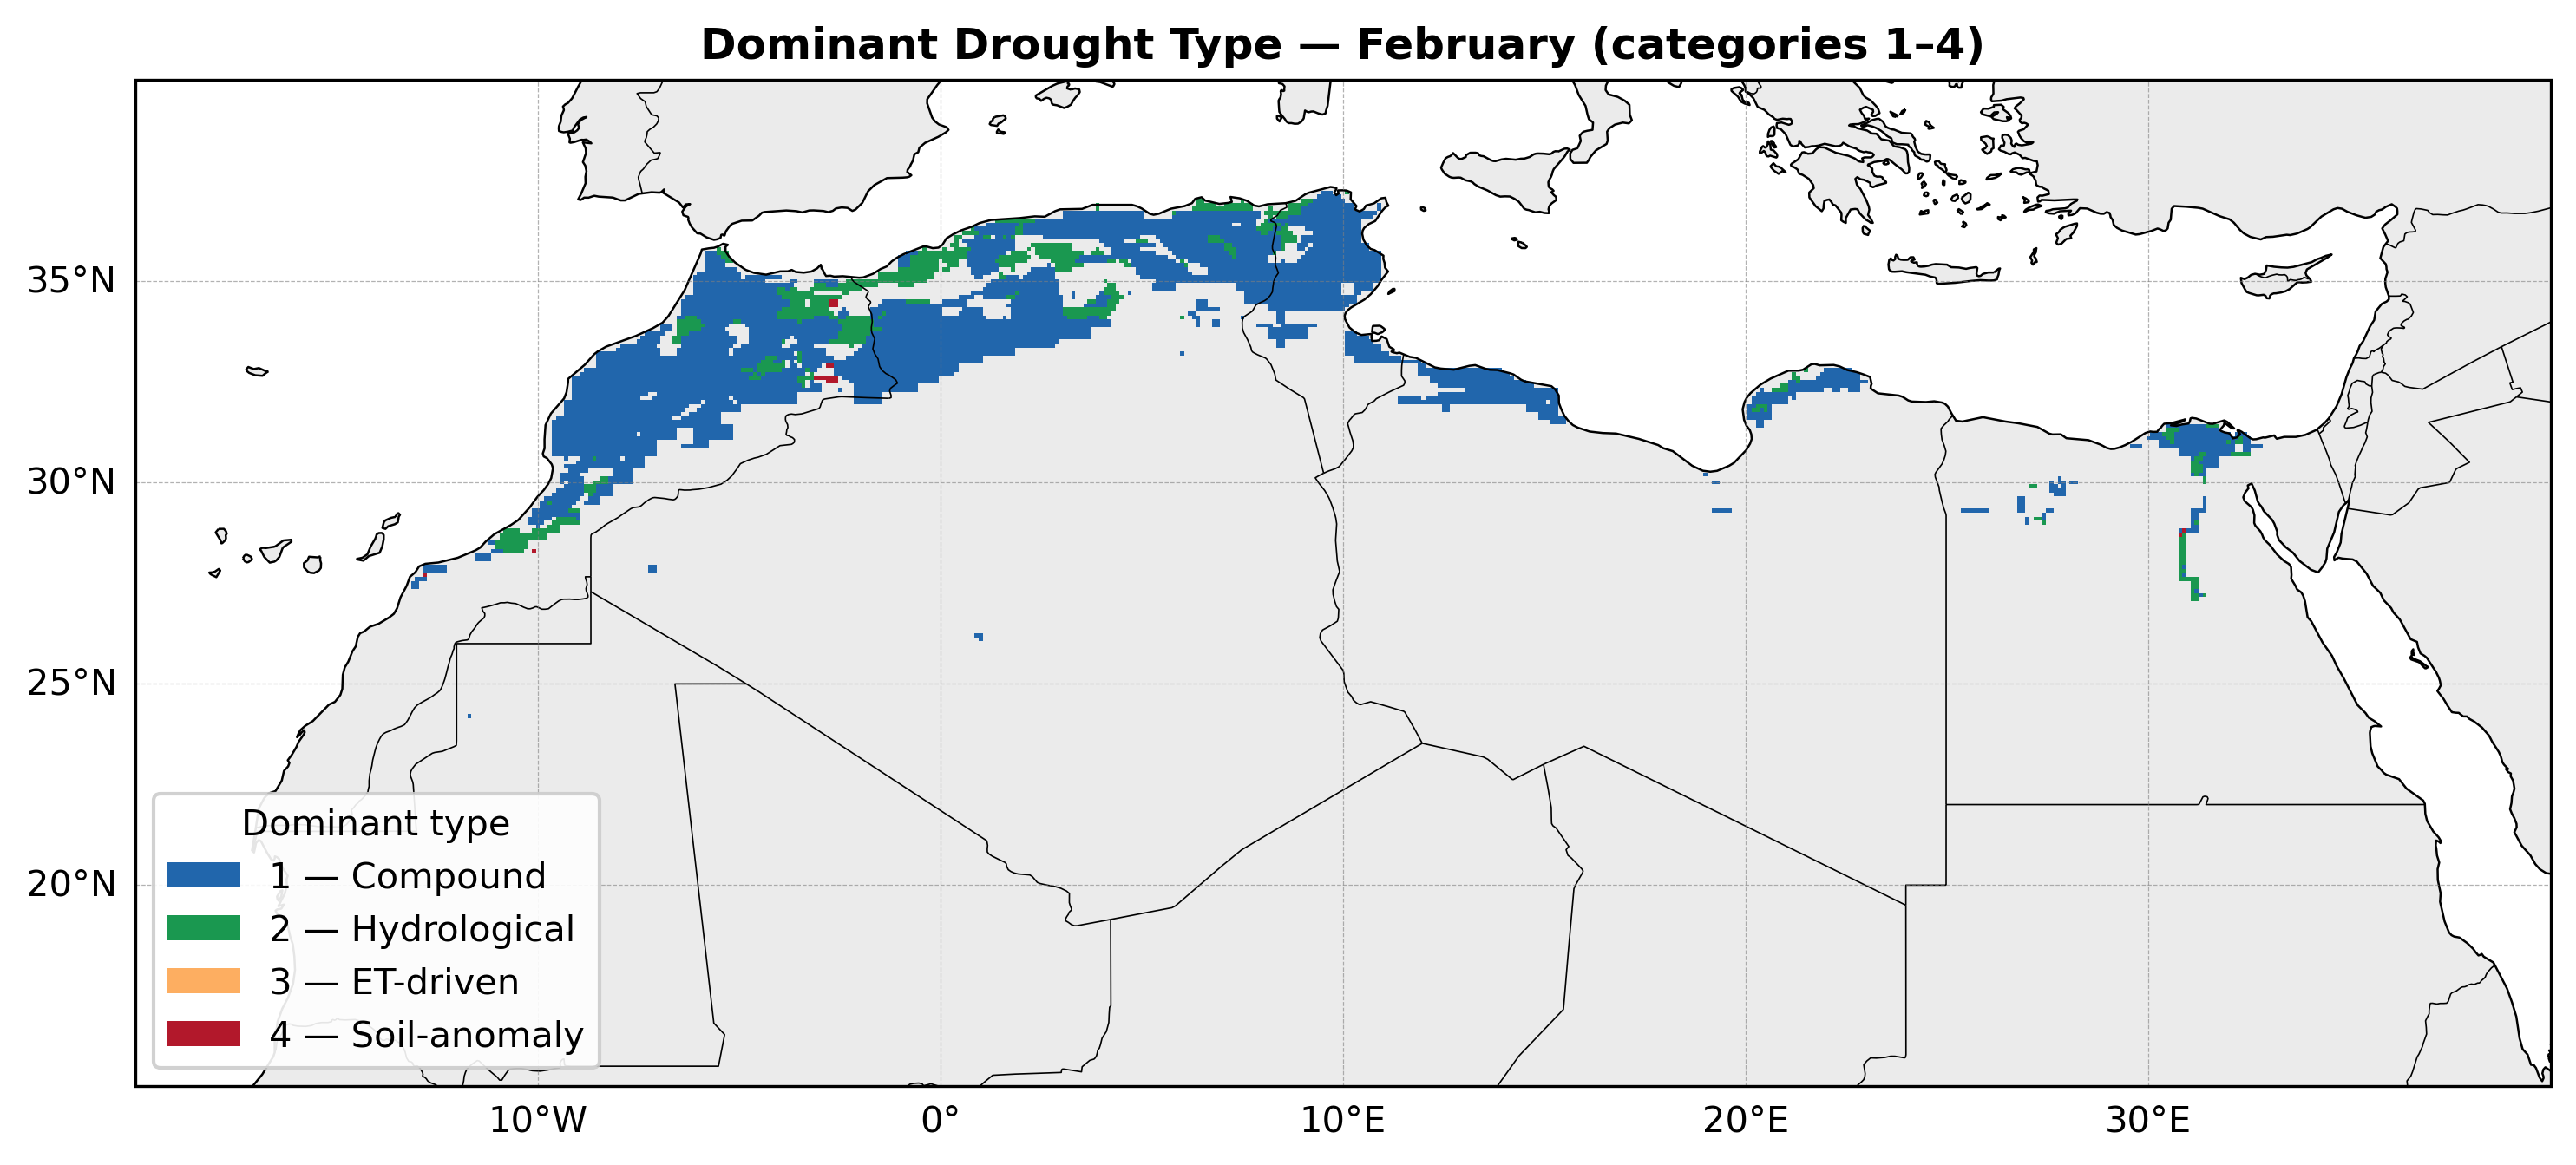

[INFO] Processing: Dominant_Drought_Type_May.nc
[DEBUG] Available variables: ['dominant_drought_type_may']


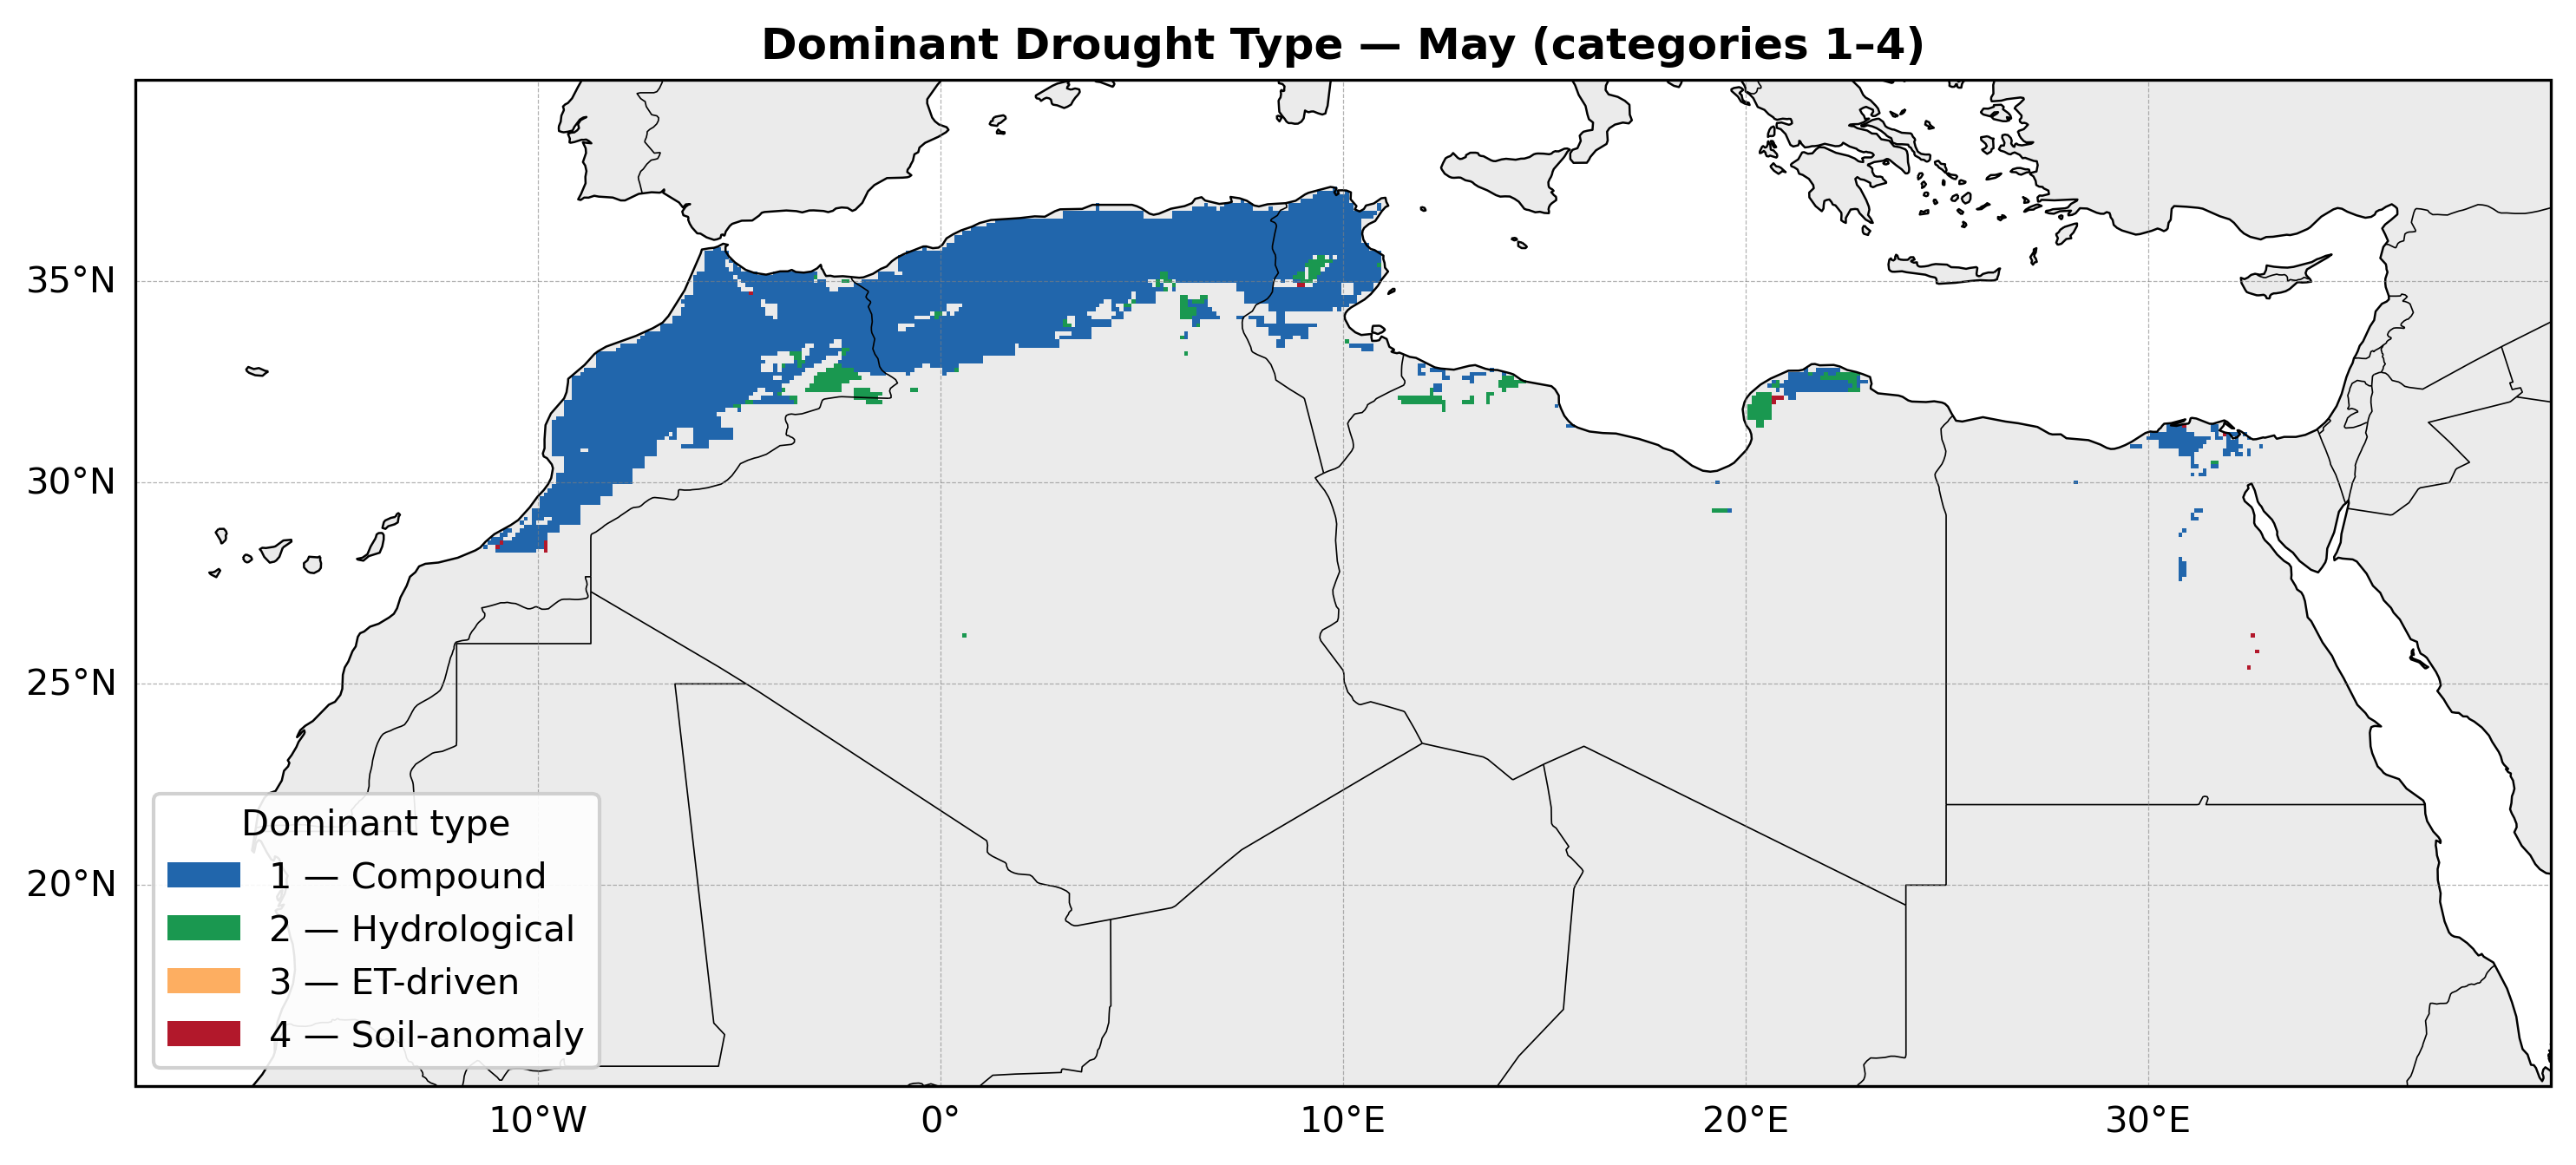

[INFO] Processing: Dominant_Drought_Type_August.nc
[DEBUG] Available variables: ['dominant_drought_type_august']


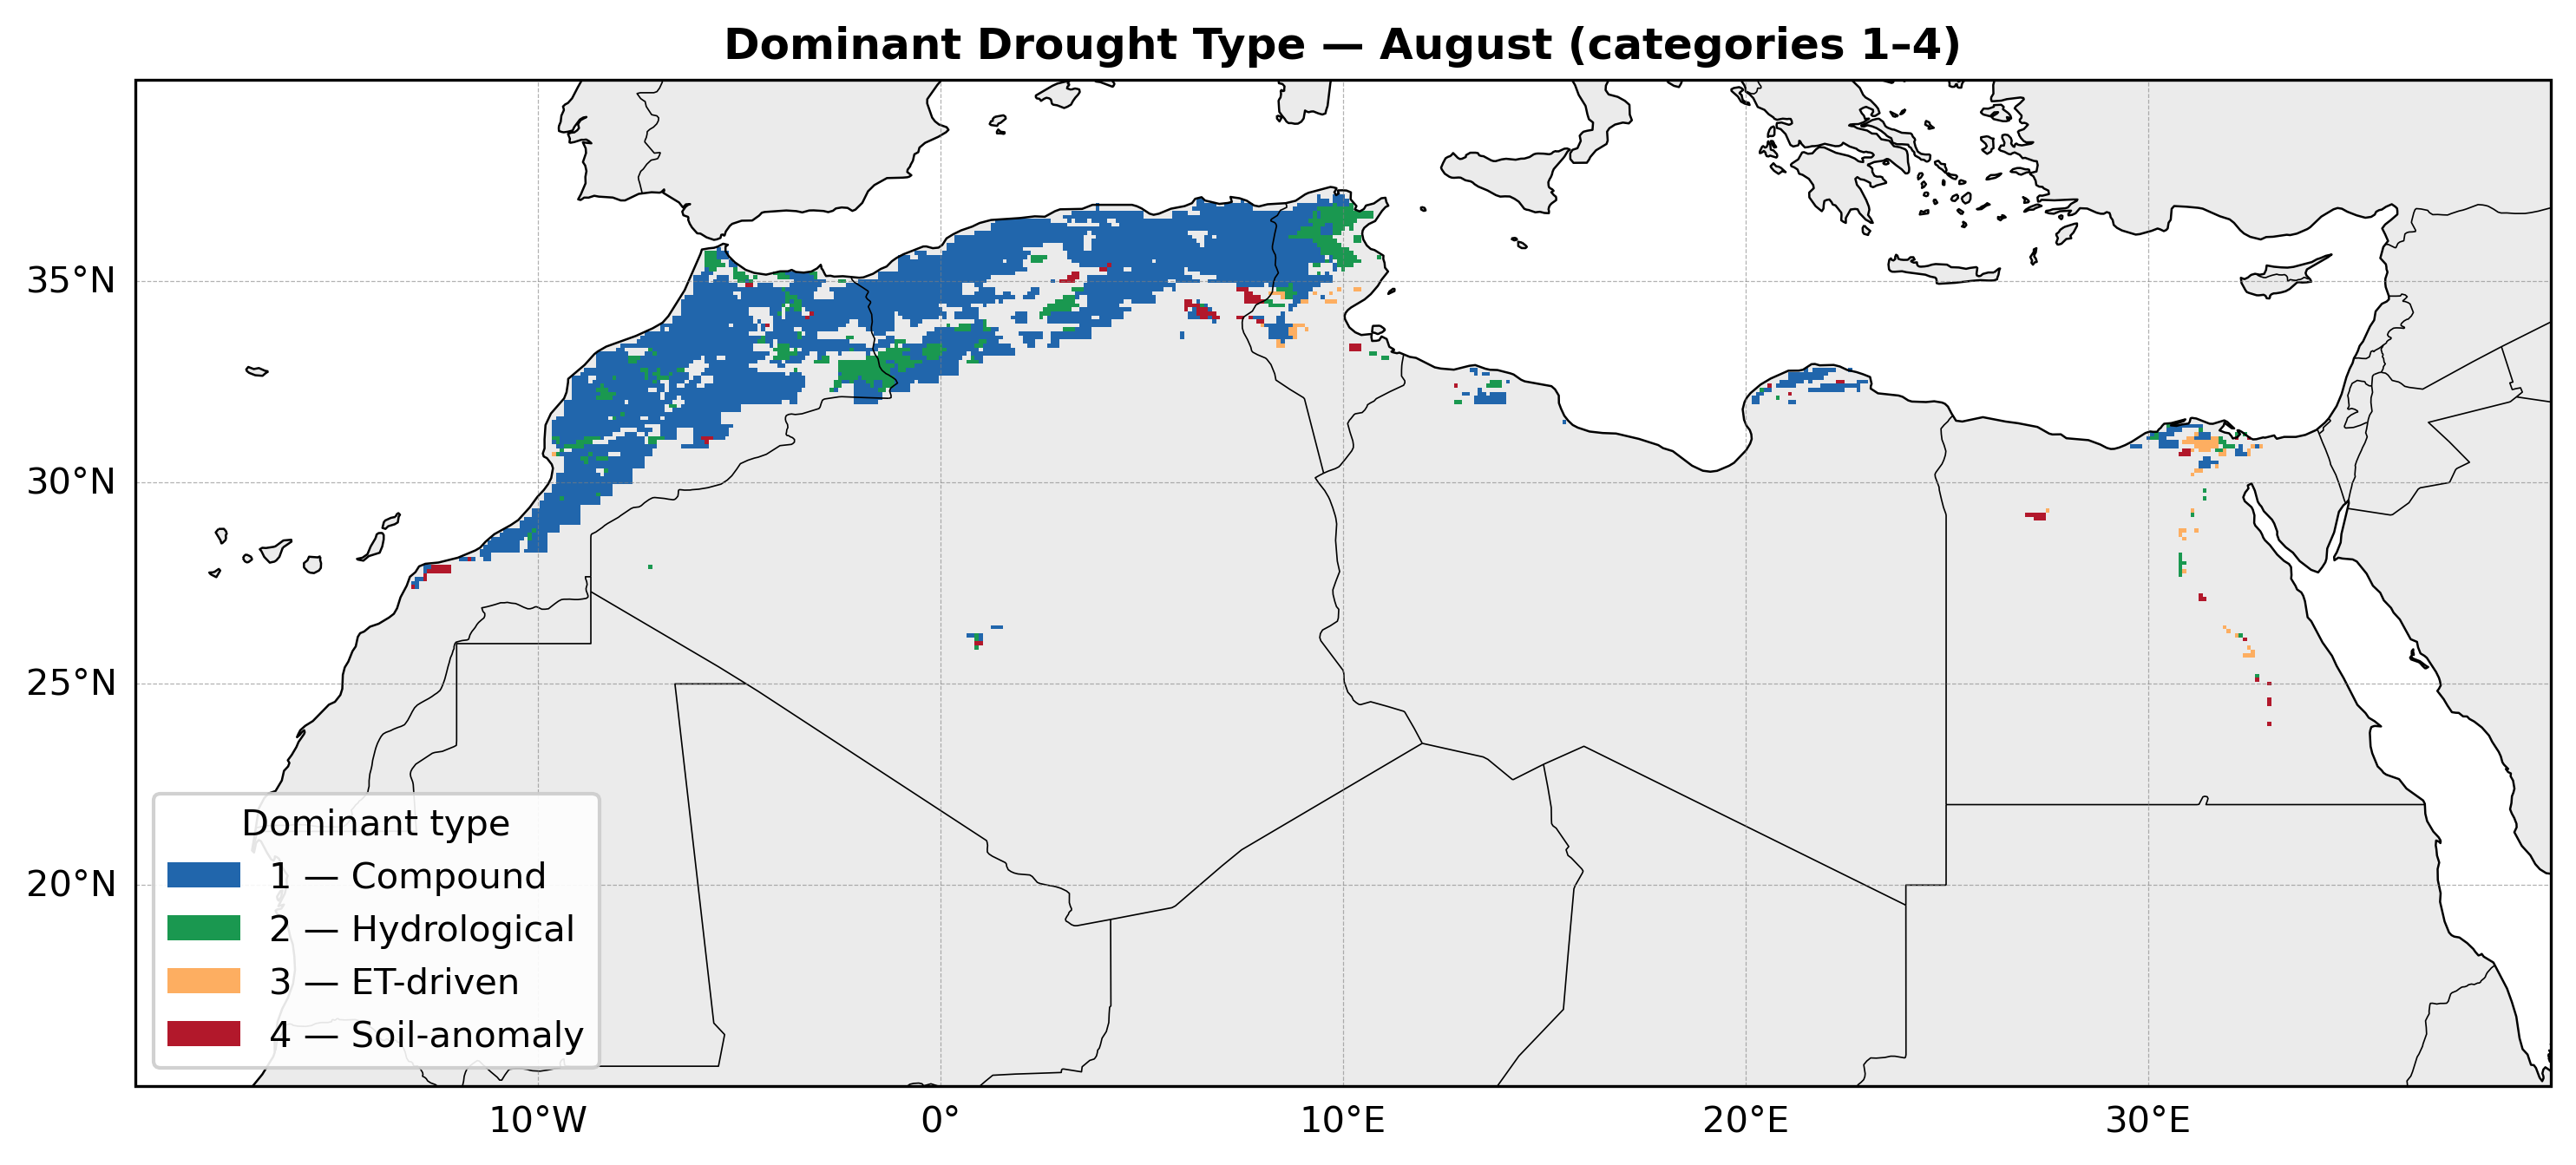

[INFO] Processing: Dominant_Drought_Type_November.nc
[DEBUG] Available variables: ['dominant_drought_type_november']


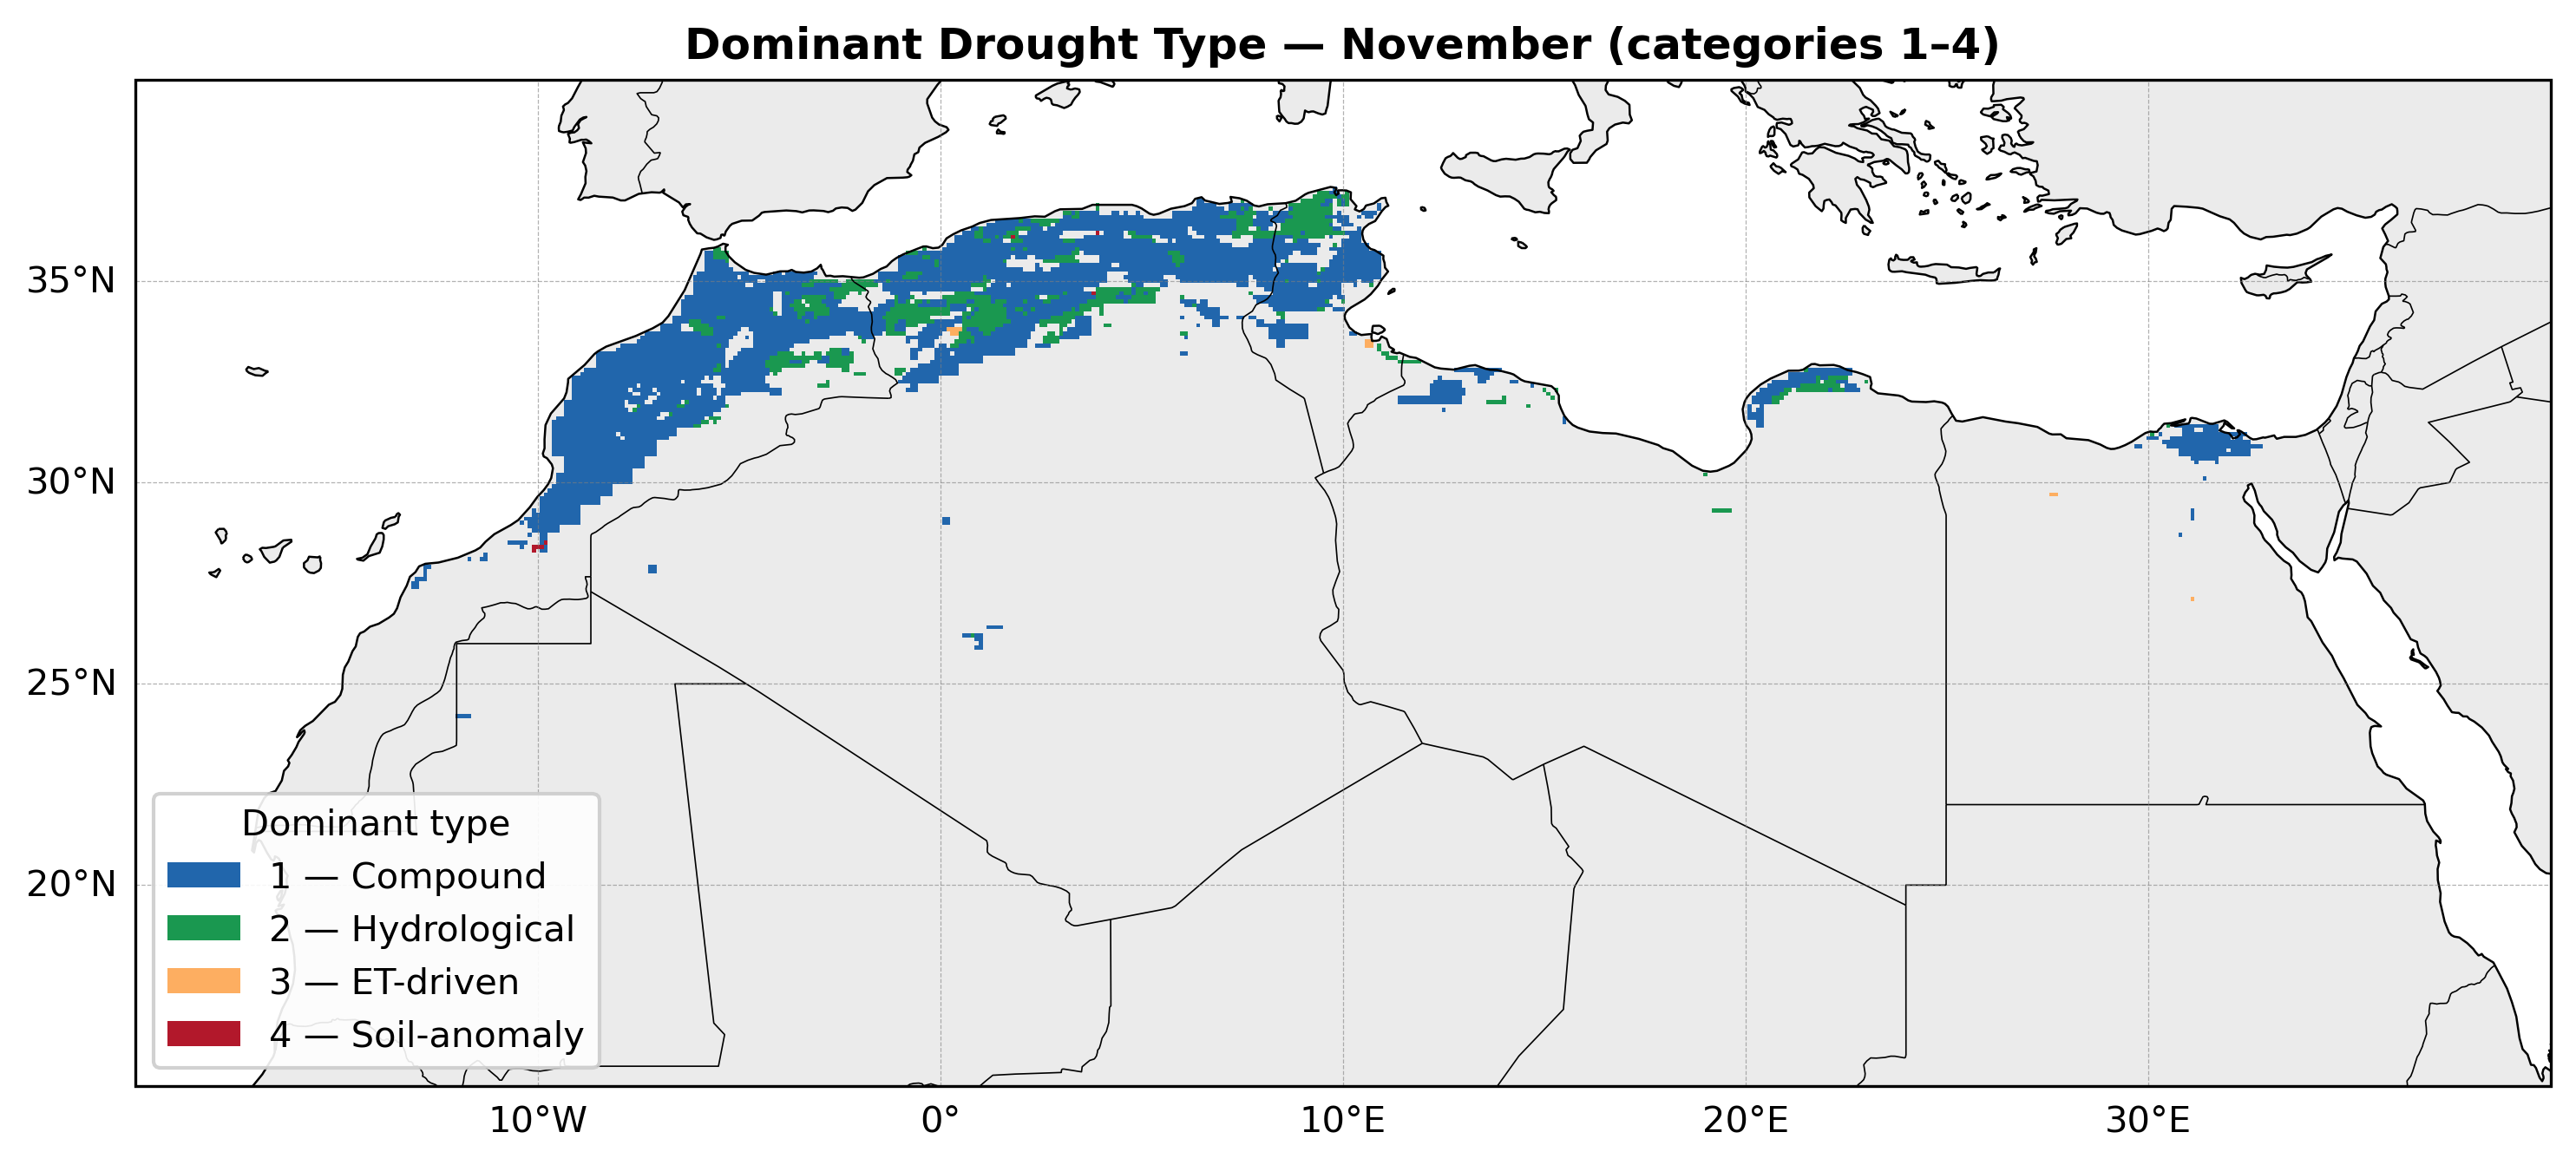

[SUCCESS] All maps generated


In [6]:
# --- MAIN LOOP ---
print("[INFO] Starting plotting...")

for fname, vname in files_vars.items():
    
    fpath = os.path.join(base_dir, fname)
    
    title_suffix = (
        fname.replace("Dominant_Drought_Type_", "")
             .replace(".nc", "")
             .replace("_", " ")
    )
    
    plot_one(fpath, vname, title_suffix)

print("[SUCCESS] All maps generated")